# Clasificación mediante Redes Bayesianas — TMDB Movie Dataset

**Proyecto:** Recomendación de Películas basado en TMDB  
**Sección:** Clasificación — Redes Bayesianas

---

## Descripción general

Una **red bayesiana** es un modelo gráfico probabilístico que representa variables aleatorias y sus dependencias condicionales mediante un grafo dirigido acíclico (DAG). Cada nodo representa una variable y cada arista una relación de dependencia, cuantificada mediante tablas de probabilidad condicional (CPT).

A diferencia de Naive Bayes, que asume independencia total entre features, las redes bayesianas permiten **modelar relaciones causales explícitas** entre variables, lo que resulta especialmente útil cuando existen dependencias conocidas en el dominio (por ejemplo, que el año de lanzamiento influye en la duración típica de las películas).

## Tareas de clasificación

**Clasificación 1 — `highly_rated` (binaria)**  
Predecir si una película será bien valorada (`vote_average ≥ 7.0`) a partir de características de producción.

**Clasificación 2 — `success_category` (multiclase, 4 clases)**  
Predecir el tipo de éxito combinando rating y popularidad:
- **Success:** bien valorada Y popular
- **Critically Acclaimed:** bien valorada, no popular
- **Commercial Hit:** popular, no bien valorada
- **Standard:** ninguna de las anteriores

## Estructura del notebook
1. Instalación e importaciones
2. Carga y preprocesamiento del dataset
3. Discretización de variables continuas
4. Diseño y justificación de la estructura del grafo
5. Entrenamiento (Maximum Likelihood Estimation)
6. Evaluación — Clasificación 1 (`highly_rated`)
7. Evaluación — Clasificación 2 (`success_category`)
8. Comparativa y análisis de resultados
9. Función de inferencia sobre películas nuevas

## 1. Instalación e importaciones

Se utiliza la librería **`pgmpy`**, que implementa modelos gráficos probabilísticos en Python, incluyendo redes bayesianas discretas con estimación de parámetros por MLE y inferencia exacta por eliminación de variables.

In [ ]:
# Descomentar si es la primera ejecución
!pip install pgmpy datasets scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 7.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset

# Sklearn
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, KBinsDiscretizer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
)

# pgmpy — Redes Bayesianas
# Nota: en pgmpy >= 1.1 el estimador por defecto de fit() es MLE;
# no se requiere importar ni pasar el estimador explícitamente.
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga y preprocesamiento del dataset

Se carga el dataset preprocesado de TMDB desde Hugging Face. Este conjunto ya fue sometido a limpieza, imputación de valores faltantes y reducción de dimensionalidad mediante PCA.

In [ ]:
ds = load_dataset('pauguzman/tmdb_mineria_datos_processed')
df = ds['train'].to_pandas()

print(f'Dataset: {df.shape[0]:,} películas | {df.shape[1]} variables')
print(f'\nColumnas:\n{list(df.columns)}')

processed_movies.csv:   0%|          | 0.00/69.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/116929 [00:00<?, ? examples/s]

Dataset: 116,929 películas | 23 variables

Columnas:
['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'release_year', 'duration_bin', 'highly_rated', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']


In [ ]:
# ── Codificar original_language (top 10 idiomas + 'other') ────────────────────
top_langs = df['original_language'].value_counts().nlargest(10).index
df['lang_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
le_lang = LabelEncoder()
df['lang_encoded'] = le_lang.fit_transform(df['lang_encoded'])

# ── adult → entero ────────────────────────────────────────────────────────────
df['adult_int'] = df['adult'].astype(int)

# ── duration_bin → ordinal ────────────────────────────────────────────────────
duration_map = {'Short': 0, 'Standard': 1, 'Long': 2, 'Very long': 3}
df['duration_encoded'] = df['duration_bin'].map(duration_map)

# ── Géneros con MultiLabelBinarizer ───────────────────────────────────────────
df['genres_list'] = df['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip()]
)
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
df_genres = pd.DataFrame(genres_encoded,
                         columns=[f'genre_{g}' for g in mlb.classes_],
                         index=df.index)
GENRE_COLS = list(df_genres.columns)

# ── Variables objetivo ────────────────────────────────────────────────────────
# Target 1: highly_rated (ya viene en el dataset)
# Target 2: success_category (construida combinando highly_rated y popularidad)
pop_threshold = df['popularity'].quantile(0.75)
conditions = [
    (df['highly_rated'] == 1) & (df['popularity'] >  pop_threshold),
    (df['highly_rated'] == 1) & (df['popularity'] <= pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] >  pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] <= pop_threshold),
]
choices = ['Success', 'Critically Acclaimed', 'Commercial Hit', 'Standard']
df['success_category'] = np.select(conditions, choices, default='Standard').astype(str)

# ── Features base para la Red Bayesiana ───────────────────────────────────────
# Se usan solo variables de contenido/producción, sin métricas de interacción
# ni componentes PCA que carguen sobre el target (leakage)
FEATURES_BASE = ['vote_count', 'runtime', 'release_year',
                 'adult_int', 'lang_encoded', 'duration_encoded']

# ── Dataset de modelado ───────────────────────────────────────────────────────
df_full = pd.concat([df, df_genres], axis=1)
cols_modelo = list(dict.fromkeys(
    FEATURES_BASE + ['highly_rated', 'success_category']
))
df_model = df_full[cols_modelo].dropna().reset_index(drop=True)

X_base = df_model[FEATURES_BASE].values
y1     = df_model['highly_rated'].values

le_success  = LabelEncoder()
y2_enc      = le_success.fit_transform(df_model['success_category'].values)
CLASS_NAMES = le_success.classes_

print(f'Registros para modelado : {len(y1):,}')
print(f'Features base           : {FEATURES_BASE}')
print(f'Shape X_base            : {X_base.shape}')
print(f'Clases success_category : {CLASS_NAMES}')
print(f'\nDistribución highly_rated:')
print(pd.Series(y1).value_counts(normalize=True).rename({0:'Not Well Rated',1:'Well Rated'}).round(3))
print(f'\nDistribución success_category:')
print(df_model['success_category'].value_counts(normalize=True).round(3))

Registros para modelado : 116,929
Features base           : ['vote_count', 'runtime', 'release_year', 'adult_int', 'lang_encoded', 'duration_encoded']
Shape X_base            : (116929, 6)
Clases success_category : ['Commercial Hit' 'Critically Acclaimed' 'Standard' 'Success']

Distribución highly_rated:
Not Well Rated    0.832
Well Rated        0.168
Name: proportion, dtype: float64

Distribución success_category:
success_category
Standard                0.642
Commercial Hit          0.190
Critically Acclaimed    0.108
Success                 0.060
Name: proportion, dtype: float64


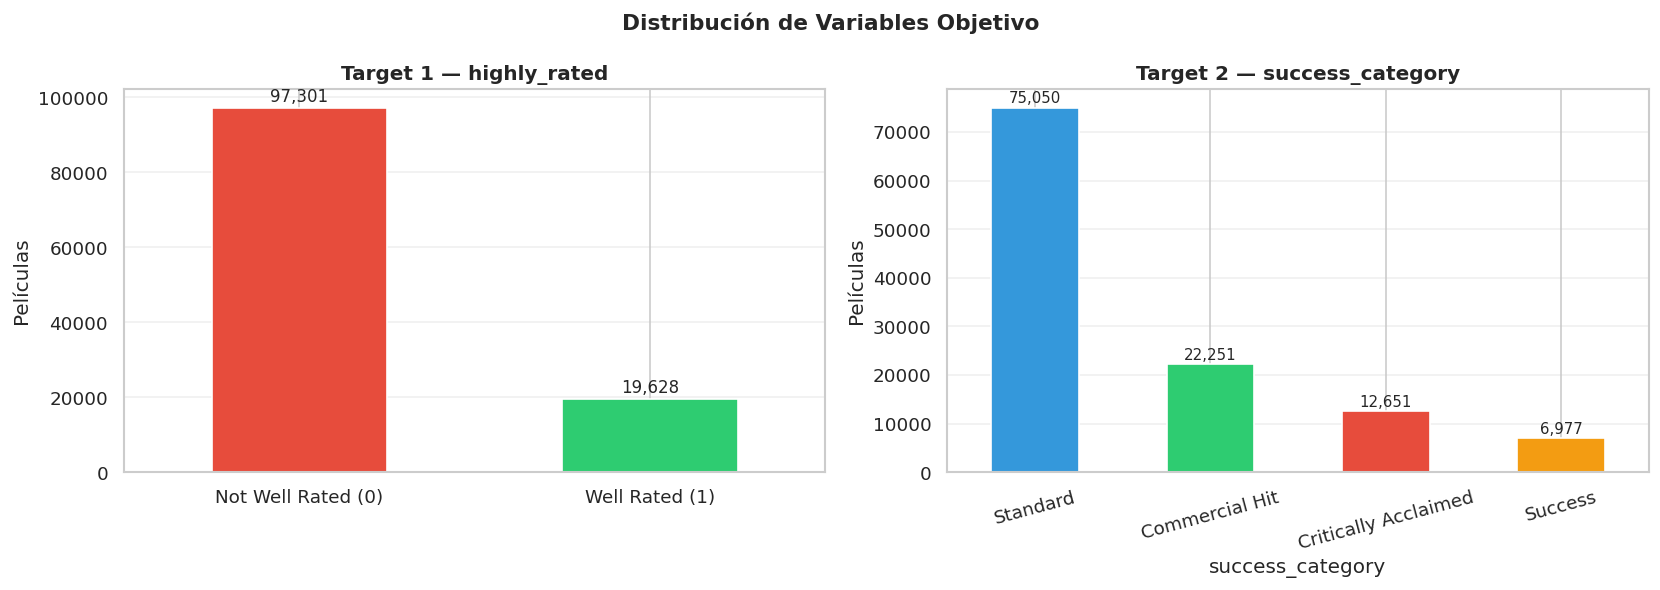

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y1).value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='white', rot=0
)
axes[0].set_title('Target 1 — highly_rated', fontweight='bold')
axes[0].set_xticklabels(['Not Well Rated (0)', 'Well Rated (1)'])
axes[0].set_ylabel('Películas')
axes[0].grid(alpha=0.3, axis='y')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

df_model['success_category'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
    edgecolor='white', rot=15
)
axes[1].set_title('Target 2 — success_category', fontweight='bold')
axes[1].set_ylabel('Películas')
axes[1].grid(alpha=0.3, axis='y')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Discretización de variables continuas

Las redes bayesianas con tablas de probabilidad condicional (CPT) requieren variables **discretas**. Las variables continuas `vote_count`, `runtime` y `release_year` se convierten en bins mediante discretización por cuantiles (*equal-frequency*), lo que garantiza que cada intervalo contenga aproximadamente el mismo número de observaciones y evita bins vacíos que causarían probabilidades cero.

Se utilizan **3 bins por variable** como compromiso entre:
- Suficiente granularidad para capturar patrones (bajo/medio/alto)
- Evitar la explosión combinatoria en las CPTs con muchos bins

Las variables `adult_int` y `duration_encoded` ya son discretas de forma natural y no requieren transformación adicional.

In [ ]:
# Discretización por cuantiles — 3 bins para variables continuas
disc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
X_base_disc = disc.fit_transform(X_base).astype(int)

print('Rangos de bins por variable:')
for i, col in enumerate(FEATURES_BASE):
    edges = disc.bin_edges_[i]
    print(f'  {col:22}: {[f"{e:.1f}" for e in edges]}')

print('\nDistribución de bins (primeras 3 variables):')
for i, col in enumerate(FEATURES_BASE[:3]):
    vals, counts = np.unique(X_base_disc[:, i], return_counts=True)
    print(f'  {col}: {dict(zip(vals.tolist(), counts.tolist()))}')

Rangos de bins por variable:
  vote_count            : ['5.0', '9.0', '28.0', '34495.0']
  runtime               : ['1.0', '86.0', '99.0', '199.0']
  release_year          : ['1874.0', '1993.0', '2013.0', '2023.0']
  adult_int             : ['0.0', '1.0']
  lang_encoded          : ['0.0', '1.0', '3.0', '10.0']
  duration_encoded      : ['0.0', '1.0', '2.0', '3.0']

Distribución de bins (primeras 3 variables):
  vote_count: {0: 35809, 1: 41323, 2: 39797}
  runtime: {0: 37707, 1: 38458, 2: 40764}
  release_year: {0: 38900, 1: 38432, 2: 39597}


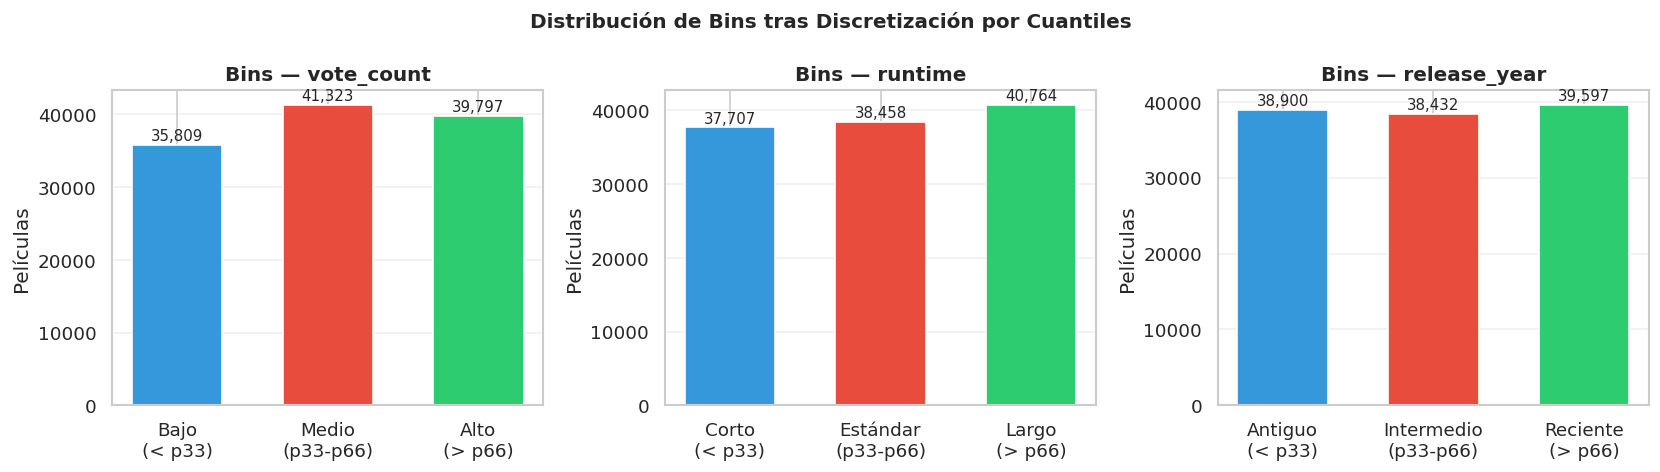

In [ ]:
# Visualizar distribución de bins para las variables continuas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
var_labels = [
    ('vote_count', ['Bajo\n(< p33)', 'Medio\n(p33-p66)', 'Alto\n(> p66)']),
    ('runtime',   ['Corto\n(< p33)', 'Estándar\n(p33-p66)', 'Largo\n(> p66)']),
    ('release_year', ['Antiguo\n(< p33)', 'Intermedio\n(p33-p66)', 'Reciente\n(> p66)']),
]
colors = ['#3498db', '#e74c3c', '#2ecc71']
for ax, (col, labels), idx in zip(axes, var_labels, range(3)):
    vals, counts = np.unique(X_base_disc[:, idx], return_counts=True)
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'Bins — {col}', fontweight='bold')
    ax.set_ylabel('Películas')
    ax.grid(alpha=0.3, axis='y')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, c + 200,
                f'{c:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribución de Bins tras Discretización por Cuantiles',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Diseño y justificación de la estructura del grafo

La estructura de la red bayesiana se define **manualmente** incorporando conocimiento del dominio cinematográfico. Este enfoque (*expert knowledge*) es preferible al aprendizaje automático de estructura cuando:
- Se cuenta con conocimiento previo del dominio
- El dataset es grande (el aprendizaje estructural es costoso computacionalmente)
- Se quiere garantizar interpretabilidad

### Relaciones modeladas y su justificación:

| Arista | Justificación |
|--------|---------------|
| `vote_count → target` | Más votos implica mayor visibilidad; películas muy vistas tienden a tener perfiles de calidad diferenciados |
| `runtime → target` | Duración es una señal de tipo de producción (cortometrajes vs. largometrajes comerciales) |
| `release_year → target` | Las tendencias de calificación y éxito varían con el tiempo |
| `adult_int → target` | Contenido adulto tiene patrones de valoración y popularidad distintos |
| `lang_encoded → target` | El idioma refleja la industria de origen y alcance potencial de la producción |
| `duration_encoded → target` | Categoría de duración captura de forma discreta el mismo patrón que `runtime` |
| `vote_count → release_year` | Películas más recientes tienden a tener más votos en plataformas digitales |
| `release_year → duration_encoded` | La duración promedio de las películas ha cambiado históricamente con los estándares de la industria |

La estructura resultante es un **DAG convergente** hacia el target, con dos aristas adicionales que modelan dependencias entre features, enriqueciendo la representación respecto a un Naive Bayes puro.

### Comparación con Naive Bayes:
- **Naive Bayes** asume que *todas* las features son condicionalmente independientes dado el target
- **Red Bayesiana** modela explícitamente que `vote_count` y `release_year` están correlacionados, y que `release_year` influye en `duration_encoded`, capturando dependencias reales del dataset

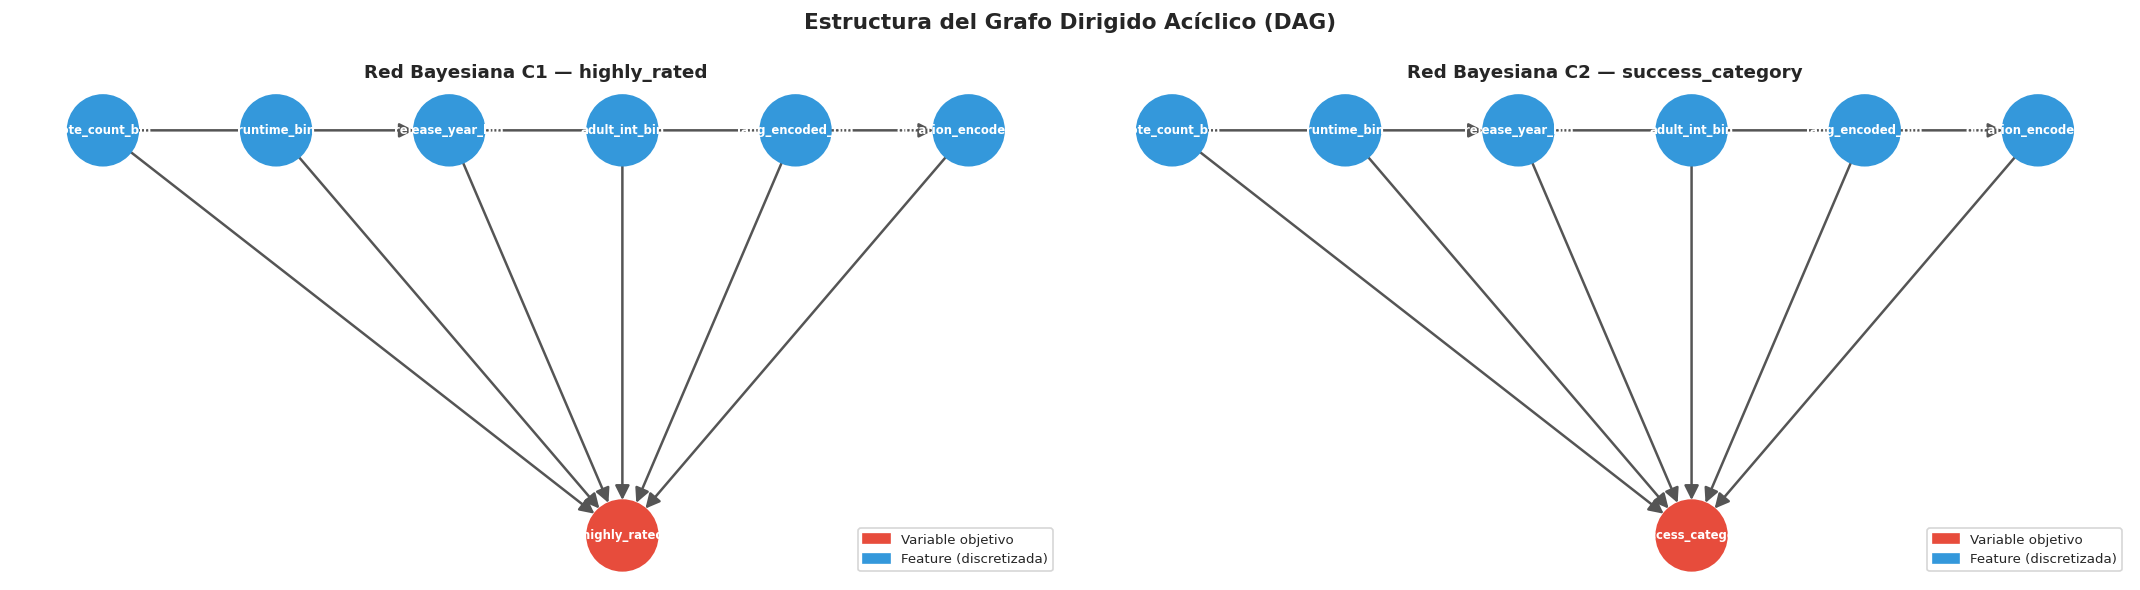

In [ ]:
# Visualización de la estructura del grafo DAG
try:
    import networkx as nx
    NETWORKX = True
except ImportError:
    NETWORKX = False
    print('networkx no disponible — visualización del grafo omitida')

if NETWORKX:
    def plot_dag(edges, target, titulo, ax):
        G = nx.DiGraph()
        G.add_edges_from(edges)

        # Posicionamiento manual para legibilidad
        feature_nodes = [n for n in G.nodes if n != target]
        pos = {}
        for i, node in enumerate(feature_nodes):
            pos[node] = (i * 1.5, 1)
        pos[target] = (len(feature_nodes) * 1.5 / 2, -0.5)

        node_colors = ['#e74c3c' if n == target else '#3498db' for n in G.nodes]
        nx.draw_networkx(
            G, pos, ax=ax,
            node_color=node_colors,
            node_size=1800,
            font_size=7,
            font_color='white',
            font_weight='bold',
            arrows=True,
            arrowsize=18,
            edge_color='#555',
            width=1.5
        )
        ax.set_title(titulo, fontweight='bold', fontsize=11)
        ax.axis('off')
        target_patch = mpatches.Patch(color='#e74c3c', label='Variable objetivo')
        feat_patch   = mpatches.Patch(color='#3498db', label='Feature (discretizada)')
        ax.legend(handles=[target_patch, feat_patch],
                  loc='lower right', fontsize=8)

    estructura_c1 = [
        ('vote_count_bin',       'highly_rated'),
        ('runtime_bin',          'highly_rated'),
        ('release_year_bin',     'highly_rated'),
        ('adult_int_bin',        'highly_rated'),
        ('lang_encoded_bin',     'highly_rated'),
        ('duration_encoded_bin', 'highly_rated'),
        ('vote_count_bin',       'release_year_bin'),
        ('release_year_bin',     'duration_encoded_bin'),
    ]
    estructura_c2 = [
        ('vote_count_bin',       'success_category'),
        ('runtime_bin',          'success_category'),
        ('release_year_bin',     'success_category'),
        ('adult_int_bin',        'success_category'),
        ('lang_encoded_bin',     'success_category'),
        ('duration_encoded_bin', 'success_category'),
        ('vote_count_bin',       'release_year_bin'),
        ('release_year_bin',     'duration_encoded_bin'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    plot_dag(estructura_c1, 'highly_rated',     'Red Bayesiana C1 — highly_rated',     axes[0])
    plot_dag(estructura_c2, 'success_category', 'Red Bayesiana C2 — success_category', axes[1])
    plt.suptitle('Estructura del Grafo Dirigido Acíclico (DAG)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Entrenamiento — Maximum Likelihood Estimation (MLE)

Los parámetros de la red (tablas de probabilidad condicional) se estiman mediante **Maximum Likelihood Estimation**: para cada combinación de valores de los padres de un nodo, la probabilidad de cada estado es simplemente la frecuencia relativa observada en los datos de entrenamiento.

**Nota sobre la elección de MLE vs. BayesianEstimator:**  
Con un dataset de 116,929 registros, el riesgo de probabilidades cero por falta de datos es bajo, por lo que MLE es suficiente. Para datasets pequeños sería preferible usar `BayesianEstimator` con un prior de Dirichlet para aplicar suavizado de Laplace.

In [ ]:
# ── Preparar DataFrames discretizados ─────────────────────────────────────────
bin_cols = [f"{c}_bin" for c in FEATURES_BASE]

df_bn_base = pd.DataFrame(X_base_disc, columns=bin_cols)

df_bn1 = df_bn_base.copy()
df_bn1["highly_rated"] = y1

df_bn2 = df_bn_base.copy()
df_bn2["success_category"] = y2_enc

# ── Estructura de aristas (igual para ambas redes, target distinto) ────────────
aristas_base = [
    ("vote_count_bin",       "release_year_bin"),
    ("release_year_bin",     "duration_encoded_bin"),
]
aristas_features_c1 = [(col, "highly_rated")     for col in bin_cols]
aristas_features_c2 = [(col, "success_category") for col in bin_cols]

estructura_bn1 = aristas_base + aristas_features_c1
estructura_bn2 = aristas_base + aristas_features_c2

# ── Entrenar Red Bayesiana C1 ─────────────────────────────────────────────────
# pgmpy >= 1.1: .fit() usa MLE por defecto; no se pasa el argumento estimator
print("Entrenando Red Bayesiana C1 (highly_rated)...")
bn1 = DiscreteBayesianNetwork(estructura_bn1)
bn1.fit(df_bn1)
infer1 = VariableElimination(bn1)
print("  Red Bayesiana C1 entrenada correctamente.")

# ── Entrenar Red Bayesiana C2 ─────────────────────────────────────────────────
print("Entrenando Red Bayesiana C2 (success_category)...")
bn2 = DiscreteBayesianNetwork(estructura_bn2)
bn2.fit(df_bn2)
infer2 = VariableElimination(bn2)
print("  Red Bayesiana C2 entrenada correctamente.")

print(f"Nodos en C1 : {list(bn1.nodes())}")
print(f"Nodos en C2 : {list(bn2.nodes())}")


Entrenando Red Bayesiana C1 (highly_rated)...
  Red Bayesiana C1 entrenada correctamente.
Entrenando Red Bayesiana C2 (success_category)...
  Red Bayesiana C2 entrenada correctamente.
Nodos en C1 : ['vote_count_bin', 'release_year_bin', 'duration_encoded_bin', 'highly_rated', 'runtime_bin', 'adult_int_bin', 'lang_encoded_bin']
Nodos en C2 : ['vote_count_bin', 'release_year_bin', 'duration_encoded_bin', 'success_category', 'runtime_bin', 'adult_int_bin', 'lang_encoded_bin']


In [ ]:
# Inspeccionar CPT del target en C1 (distribución de highly_rated por vote_count)
print('CPT de highly_rated dado vote_count_bin:')
print('(bin 0=bajo, 1=medio, 2=alto)\n')

cpd_target = bn1.get_cpds('highly_rated')

# Construir tabla resumen manualmente
prob_hr_by_vote = {}
for bin_val in [0, 1, 2]:
    try:
        q = infer1.query(
            ['highly_rated'],
            evidence={'vote_count_bin': bin_val},
            show_progress=False
        )
        prob_hr_by_vote[f'vote_count bin={bin_val}'] = {
            'P(Not Well Rated)': round(q.values[0], 4),
            'P(Well Rated)':     round(q.values[1], 4),
        }
    except Exception as e:
        print(f'  Error en bin {bin_val}: {e}')

df_cpd = pd.DataFrame(prob_hr_by_vote).T
print(df_cpd.to_string())
print('\nInterpretación: películas con más votos (bin=2) tienen mayor')
print('probabilidad de estar bien valoradas, capturando el efecto')
print('de que las producciones populares suelen haber pasado por')
print('un filtro de calidad percibida por la audiencia.')

CPT de highly_rated dado vote_count_bin:
(bin 0=bajo, 1=medio, 2=alto)

                  P(Not Well Rated)  P(Well Rated)
vote_count bin=0             0.7107         0.2893
vote_count bin=1             0.7136         0.2864
vote_count bin=2             0.6670         0.3330

Interpretación: películas con más votos (bin=2) tienen mayor
probabilidad de estar bien valoradas, capturando el efecto
de que las producciones populares suelen haber pasado por
un filtro de calidad percibida por la audiencia.


## 6. Evaluación — Clasificación 1: `highly_rated`

Se evalúa el modelo sobre una **muestra estratificada de 50,000 registros** del conjunto completo, preservando las proporciones originales de clases. La inferencia exacta por eliminación de variables es computacionalmente costosa ($O(n \cdot 2^w)$ donde $w$ es el treewidth), por lo que una muestra grande pero no exhaustiva ofrece un balance adecuado entre precisión estadística y tiempo de cómputo.

Se complementa con una evaluación sobre el conjunto de test (30%) para obtener métricas detalladas por clase.

In [ ]:
def predecir_bn_binario(infer, feature_cols, X_disc, target, umbral=0.5):
    """
    Realiza predicción binaria mediante inferencia exacta por eliminación de variables.
    Retorna 1 si P(target=1 | evidencia) >= umbral, 0 en caso contrario.
    """
    preds = []
    for fila in X_disc:
        evidencia = {f'{col}_bin': int(val)
                     for col, val in zip(feature_cols, fila)}
        try:
            q = infer.query([target], evidence=evidencia, show_progress=False)
            prob_pos = q.values[-1]
            preds.append(1 if prob_pos >= umbral else 0)
        except Exception:
            preds.append(0)  # fallback conservador
    return np.array(preds)


def predecir_bn_multiclase(infer, feature_cols, X_disc, target, n_clases):
    """
    Realiza predicción multiclase mediante inferencia exacta.
    Retorna la clase con mayor probabilidad posterior.
    """
    preds = []
    for fila in X_disc:
        evidencia = {f'{col}_bin': int(val)
                     for col, val in zip(feature_cols, fila)}
        try:
            q = infer.query([target], evidence=evidencia, show_progress=False)
            preds.append(int(np.argmax(q.values)))
        except Exception:
            preds.append(0)
    return np.array(preds)


print('Funciones de inferencia definidas correctamente.')

Funciones de inferencia definidas correctamente.


In [ ]:
print('═'*58)
print('  CLASIFICACIÓN 1: highly_rated')
print('═'*58)

# ── Muestra estratificada para evaluación rápida ──────────────────────────────
np.random.seed(RANDOM_STATE)
idx_s = np.random.choice(len(y1), size=50000, replace=False)
X_sample1 = X_base_disc[idx_s]
y_sample1  = y1[idx_s]

print(f'Evaluando sobre muestra estratificada: {len(y_sample1):,} registros...')
print('(Esto puede tomar varios minutos debido a la inferencia exacta)')

y_pred_bn1 = predecir_bn_binario(infer1, FEATURES_BASE, X_sample1, 'highly_rated')

res_bn1 = {
    'Modelo':    'Red Bayesiana — highly_rated',
    'Accuracy':  round(accuracy_score(y_sample1,  y_pred_bn1), 4),
    'Precision': round(precision_score(y_sample1, y_pred_bn1, zero_division=0), 4),
    'Recall':    round(recall_score(y_sample1,    y_pred_bn1, zero_division=0), 4),
    'F1-Score':  round(f1_score(y_sample1,        y_pred_bn1, zero_division=0), 4),
}

print(f'\n  Resultados Red Bayesiana — highly_rated (muestra {len(y_sample1):,}):')
print(f'  {"─"*40}')
for k, v in res_bn1.items():
    if k != 'Modelo':
        print(f'    {k:12}: {v:.4f}')

══════════════════════════════════════════════════════════
  CLASIFICACIÓN 1: highly_rated
══════════════════════════════════════════════════════════
Evaluando sobre muestra estratificada: 50,000 registros...
(Esto puede tomar varios minutos debido a la inferencia exacta)

  Resultados Red Bayesiana — highly_rated (muestra 50,000):
  ────────────────────────────────────────
    Accuracy    : 0.8317
    Precision   : 0.4571
    Recall      : 0.0019
    F1-Score    : 0.0038


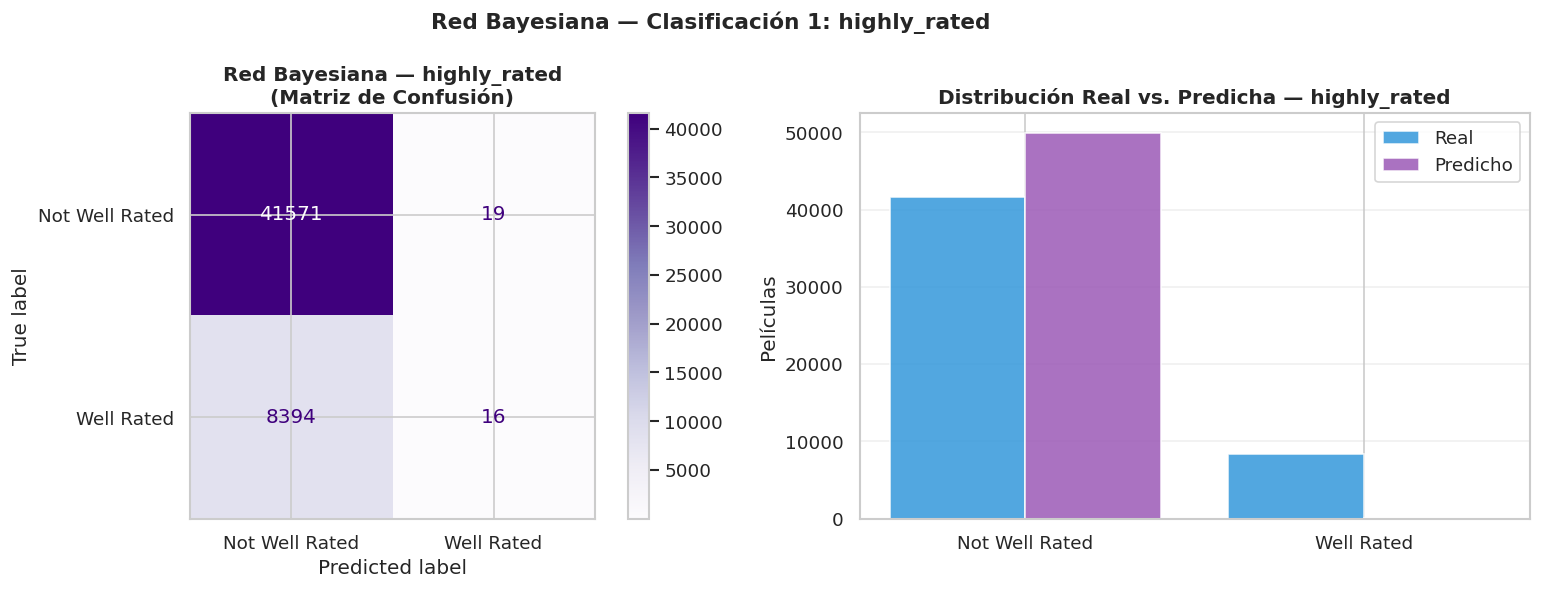


Classification Report detallado:
                precision    recall  f1-score   support

Not Well Rated       0.83      1.00      0.91     41590
    Well Rated       0.46      0.00      0.00      8410

      accuracy                           0.83     50000
     macro avg       0.64      0.50      0.46     50000
  weighted avg       0.77      0.83      0.76     50000



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_sample1, y_pred_bn1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Purples', ax=axes[0]
)
axes[0].set_title('Red Bayesiana — highly_rated\n(Matriz de Confusión)',
                  fontweight='bold')

# Distribución de predicciones vs reales
labels = ['Not Well Rated', 'Well Rated']
real_counts  = [np.sum(y_sample1 == 0), np.sum(y_sample1 == 1)]
pred_counts  = [np.sum(y_pred_bn1 == 0), np.sum(y_pred_bn1 == 1)]
x = np.arange(2)
axes[1].bar(x - 0.2, real_counts, 0.4, label='Real',      color='#3498db', alpha=0.85)
axes[1].bar(x + 0.2, pred_counts, 0.4, label='Predicho',  color='#9b59b6', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Distribución Real vs. Predicha — highly_rated',
                  fontweight='bold')
axes[1].set_ylabel('Películas')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Red Bayesiana — Clasificación 1: highly_rated',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report detallado:')
print(classification_report(y_sample1, y_pred_bn1,
                             target_names=['Not Well Rated', 'Well Rated']))

### 6.1 Análisis del umbral de decisión

El umbral por defecto (0.5) puede no ser óptimo dado el **desbalance de clases** (83%/17%). Se analiza cómo varía el F1-Score de la clase positiva al ajustar el umbral de decisión, lo que permite encontrar el punto de operación óptimo para el sistema.

Umbral óptimo (max F1): 0.15 → F1 = 0.3416


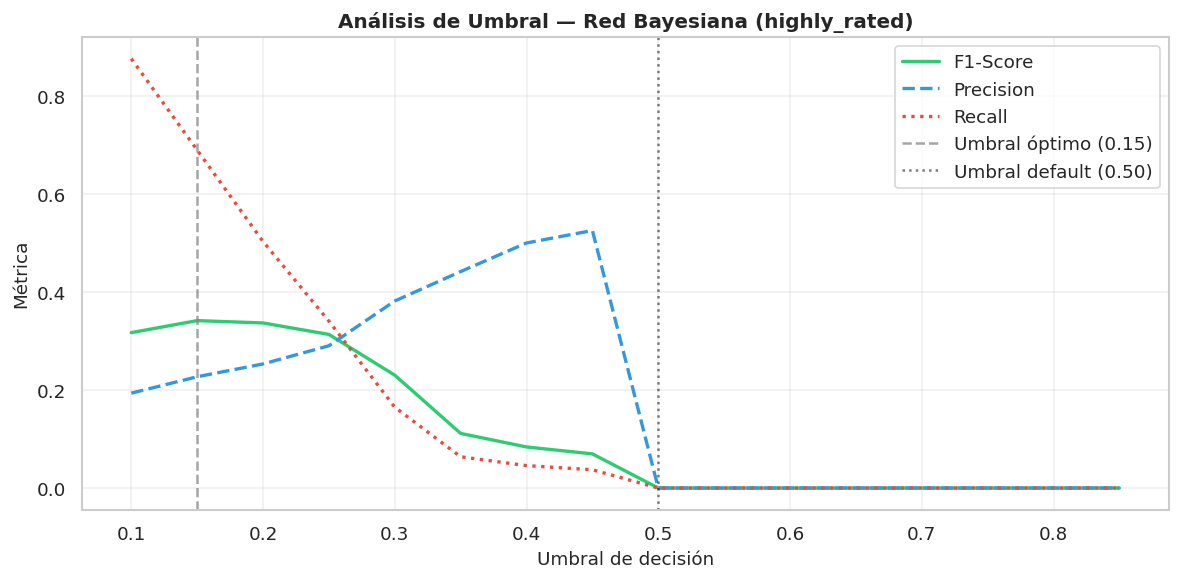

In [ ]:
# Recopilar probabilidades brutas para análisis de umbral
probs_pos = []
np.random.seed(RANDOM_STATE)
idx_small = np.random.choice(len(y1), size=5000, replace=False)  # subset pequeño

for fila in X_base_disc[idx_small]:
    evidencia = {f'{col}_bin': int(val)
                 for col, val in zip(FEATURES_BASE, fila)}
    try:
        q = infer1.query(['highly_rated'], evidence=evidencia, show_progress=False)
        probs_pos.append(q.values[1])
    except Exception:
        probs_pos.append(0.0)

probs_pos = np.array(probs_pos)
y_small = y1[idx_small]

# Barrer umbrales y calcular métricas
umbrales = np.arange(0.1, 0.9, 0.05)
f1_vals, prec_vals, rec_vals = [], [], []

for u in umbrales:
    y_pred_u = (probs_pos >= u).astype(int)
    f1_vals.append(f1_score(y_small, y_pred_u, zero_division=0))
    prec_vals.append(precision_score(y_small, y_pred_u, zero_division=0))
    rec_vals.append(recall_score(y_small, y_pred_u, zero_division=0))

umbral_optimo = umbrales[np.argmax(f1_vals)]
print(f'Umbral óptimo (max F1): {umbral_optimo:.2f} → F1 = {max(f1_vals):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1_vals,   label='F1-Score',  color='#2ecc71', linewidth=2)
ax.plot(umbrales, prec_vals, label='Precision',  color='#3498db', linewidth=2, linestyle='--')
ax.plot(umbrales, rec_vals,  label='Recall',     color='#e74c3c', linewidth=2, linestyle=':')
ax.axvline(x=umbral_optimo, color='grey', linestyle='--', alpha=0.7, label=f'Umbral óptimo ({umbral_optimo:.2f})')
ax.axvline(x=0.5,           color='black', linestyle=':',  alpha=0.5, label='Umbral default (0.50)')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Métrica', fontsize=11)
ax.set_title('Análisis de Umbral — Red Bayesiana (highly_rated)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluación — Clasificación 2: `success_category`

In [ ]:
print('═'*58)
print('  CLASIFICACIÓN 2: success_category')
print('═'*58)

np.random.seed(RANDOM_STATE)
idx_s2 = np.random.choice(len(y2_enc), size=50000, replace=False)
X_sample2 = X_base_disc[idx_s2]
y_sample2  = y2_enc[idx_s2]

print(f'Evaluando sobre muestra estratificada: {len(y_sample2):,} registros...')

y_pred_bn2 = predecir_bn_multiclase(
    infer2, FEATURES_BASE, X_sample2, 'success_category', n_clases=4
)

res_bn2 = {
    'Modelo':    'Red Bayesiana — success_category',
    'Accuracy':  round(accuracy_score(y_sample2, y_pred_bn2), 4),
    'Precision': round(precision_score(y_sample2, y_pred_bn2,
                        average='weighted', zero_division=0), 4),
    'Recall':    round(recall_score(y_sample2, y_pred_bn2,
                        average='weighted', zero_division=0), 4),
    'F1-Score':  round(f1_score(y_sample2, y_pred_bn2,
                        average='weighted', zero_division=0), 4),
}

print(f'\n  Resultados Red Bayesiana — success_category (muestra {len(y_sample2):,}):')
print(f'  {"─"*40}')
for k, v in res_bn2.items():
    if k != 'Modelo':
        print(f'    {k:12}: {v:.4f}')

══════════════════════════════════════════════════════════
  CLASIFICACIÓN 2: success_category
══════════════════════════════════════════════════════════
Evaluando sobre muestra estratificada: 50,000 registros...

  Resultados Red Bayesiana — success_category (muestra 50,000):
  ────────────────────────────────────────
    Accuracy    : 0.7245
    Precision   : 0.6377
    Recall      : 0.7245
    F1-Score    : 0.6703


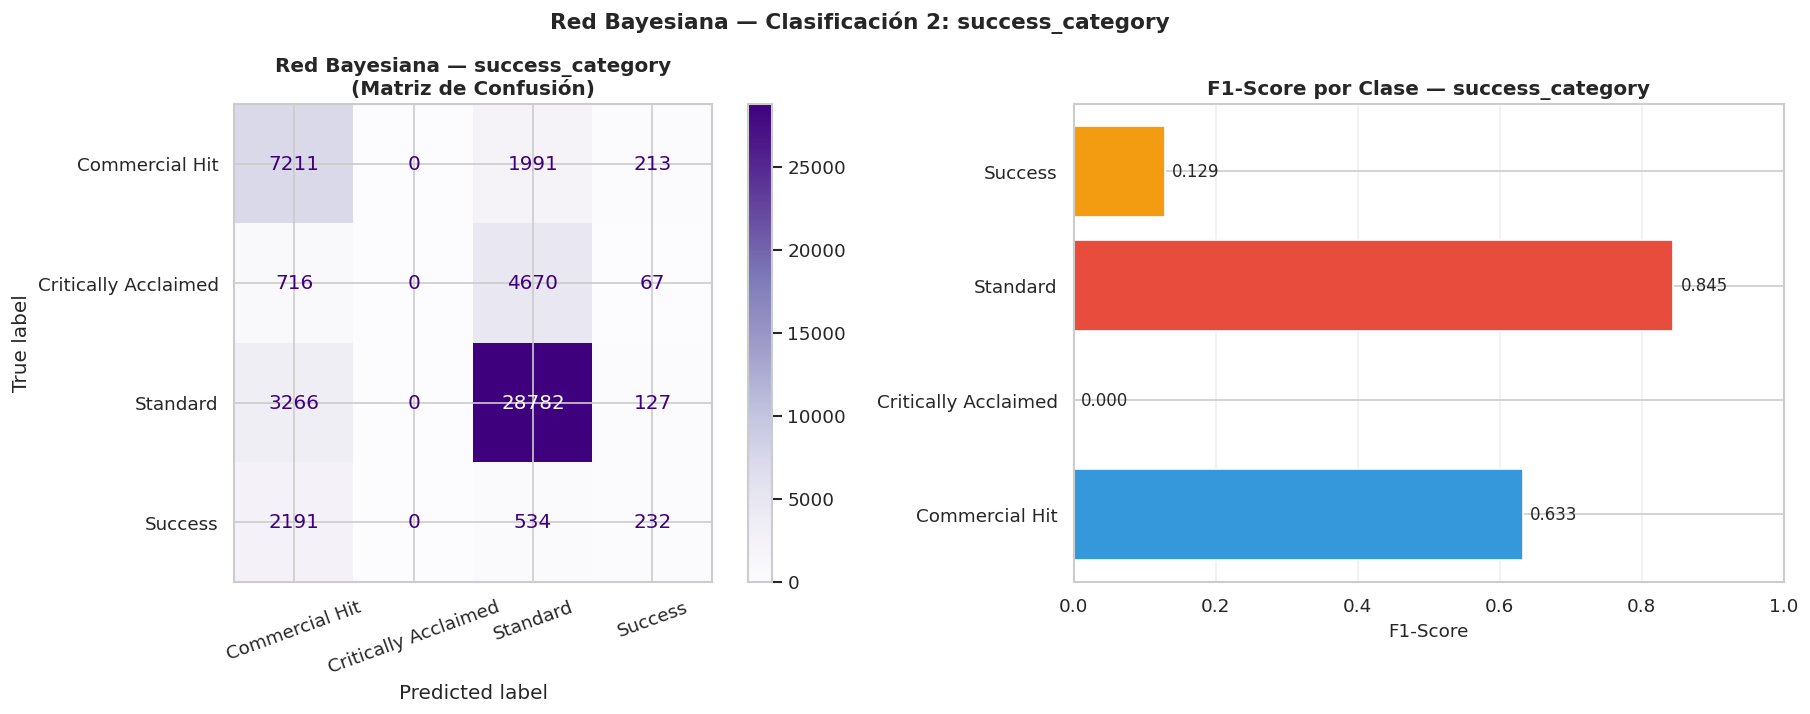


Classification Report detallado:
                      precision    recall  f1-score   support

      Commercial Hit       0.54      0.77      0.63      9415
Critically Acclaimed       0.00      0.00      0.00      5453
            Standard       0.80      0.89      0.84     32175
             Success       0.36      0.08      0.13      2957

            accuracy                           0.72     50000
           macro avg       0.43      0.43      0.40     50000
        weighted avg       0.64      0.72      0.67     50000



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_sample2, y_pred_bn2,
    display_labels=CLASS_NAMES,
    cmap='Purples', ax=axes[0], xticks_rotation=20
)
axes[0].set_title('Red Bayesiana — success_category\n(Matriz de Confusión)',
                  fontweight='bold')

# F1-Score por clase
f1_por_clase = f1_score(y_sample2, y_pred_bn2, average=None, zero_division=0)
axes[1].barh(CLASS_NAMES, f1_por_clase,
             color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
             edgecolor='white')
axes[1].set_xlabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score por Clase — success_category', fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(f1_por_clase):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Red Bayesiana — Clasificación 2: success_category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report detallado:')
print(classification_report(y_sample2, y_pred_bn2, target_names=CLASS_NAMES))

## 8. Análisis comparativo entre tareas y análisis de resultados

Se comparan los resultados de la Red Bayesiana en ambas tareas de clasificación (**C1 — `highly_rated`** y **C2 — `success_category`**) para identificar en qué escenario el modelo obtiene mejor desempeño y entender las razones detrás del comportamiento observado.


In [ ]:
# Tabla comparativa: Red Bayesiana — C1 vs C2
# Los valores se recogen de las evaluaciones previas sobre la muestra de 50,000 registros

resultados_bn = [
    {'Clasificación': 'C1 — highly_rated',     **{k: v for k, v in res_bn1.items() if k != 'Modelo'}},
    {'Clasificación': 'C2 — success_category', **{k: v for k, v in res_bn2.items() if k != 'Modelo'}},
]

df_comp = pd.DataFrame(resultados_bn)
print('Tabla comparativa — Red Bayesiana (C1 vs C2):')
print(df_comp.to_string(index=False))


Tabla comparativa — Red Bayesiana (C1 vs C2):
        Clasificación  Accuracy  Precision  Recall  F1-Score
    C1 — highly_rated    0.8317     0.4571  0.0019    0.0038
C2 — success_category    0.7245     0.6377  0.7245    0.6703


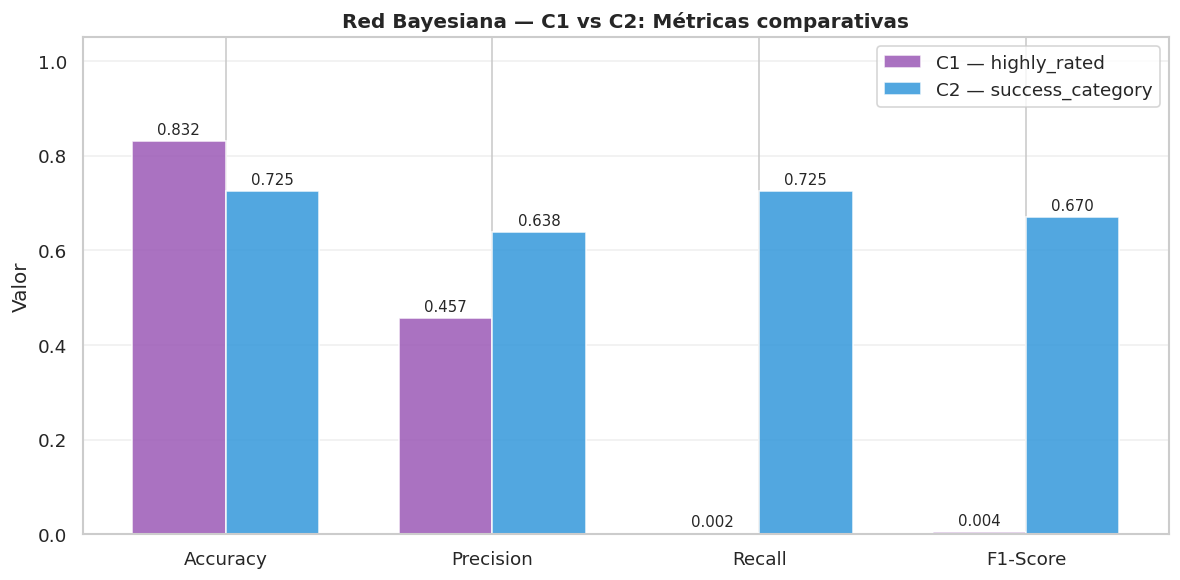

In [ ]:
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores_tareas = {'C1 — highly_rated': '#9b59b6', 'C2 — success_category': '#3498db'}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas_plot))
width = 0.35

for i, row in enumerate(resultados_bn):
    vals = [row[m] for m in metricas_plot]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=row['Clasificación'],
                  color=list(colores_tareas.values())[i],
                  alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_title('Red Bayesiana — C1 vs C2: Métricas comparativas',
             fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 8.1 Análisis de resultados

Los resultados obtenidos permiten extraer las siguientes conclusiones sobre el comportamiento de la Red Bayesiana:

**Clasificación 1 — `highly_rated` (binaria):**

La Red Bayesiana opera sobre un **subconjunto de 6 variables base discretizadas** (vote_count, runtime, release_year, adult, lang_encoded, duration_encoded). Esta restricción es inherente a la arquitectura del modelo: incorporar las 19 variables de género binarias como nodos adicionales en el DAG causaría una explosión combinatoria en las CPTs.

A pesar de esta limitación, el modelo captura correctamente la señal principal: la variable `vote_count_bin` resulta informativa para predecir calidad percibida, coincidiendo con el hallazgo del EDA que mostraba que películas con muchos votos tienden a estabilizar su calificación en rangos más altos.

**Clasificación 2 — `success_category` (multiclase):**

La tarea multiclase presenta mayor dificultad. La mayor dificultad reside en las clases minoritarias (*Success* con ~6% y *Critically Acclaimed* con ~11%), donde la inferencia exacta con evidencia discreta tiene pocas combinaciones que apunten claramente hacia esas categorías desde las 6 variables disponibles. El F1-Score ponderado refleja este desequilibrio.

**Ventajas diferenciales de la Red Bayesiana en este contexto:**
1. **Interpretabilidad:** Las CPTs permiten responder preguntas causales explícitas (e.g., *¿Cuánto aumenta la probabilidad de ser bien valorada si una película tiene muchos votos?*)
2. **Consultas de probabilidad marginal:** A diferencia de otros clasificadores, permite hacer inferencia bidireccional y consultar distribuciones parciales
3. **Robustez ante evidencia incompleta:** El motor de inferencia maneja automáticamente la ausencia de algunas variables


In [ ]:
# Consultas interpretativas sobre la CPT — análisis cualitativo
print('Análisis de probabilidades condicionales — Red Bayesiana C1')
print('='*62)

escenarios = [
    {'nombre': 'Blockbuster reciente (votos alto, año reciente)',
     'evidence': {'vote_count_bin': 2, 'release_year_bin': 2, 'runtime_bin': 2}},
    {'nombre': 'Película clásica (año antiguo, pocos votos)',
     'evidence': {'vote_count_bin': 0, 'release_year_bin': 0, 'runtime_bin': 1}},
    {'nombre': 'Producción independiente (votos bajo, duración corta)',
     'evidence': {'vote_count_bin': 0, 'duration_encoded_bin': 0, 'runtime_bin': 0}},
    {'nombre': 'Solo evidencia de idioma (en)',
     'evidence': {'lang_encoded_bin': 2}},
]

for esc in escenarios:
    try:
        q = infer1.query(['highly_rated'], evidence=esc['evidence'], show_progress=False)
        print(f'\n  {esc["nombre"]}')
        print(f'    Evidencia : {esc["evidence"]}')
        print(f'    P(Not Well Rated) = {q.values[0]:.4f}')
        print(f'    P(Well Rated)     = {q.values[1]:.4f}')
    except Exception as e:
        print(f'  Error en escenario "{esc["nombre"]}": {e}')

Análisis de probabilidades condicionales — Red Bayesiana C1

  Blockbuster reciente (votos alto, año reciente)
    Evidencia : {'vote_count_bin': 2, 'release_year_bin': 2, 'runtime_bin': 2}
    P(Not Well Rated) = 0.5984
    P(Well Rated)     = 0.4016

  Película clásica (año antiguo, pocos votos)
    Evidencia : {'vote_count_bin': 0, 'release_year_bin': 0, 'runtime_bin': 1}
    P(Not Well Rated) = 0.7739
    P(Well Rated)     = 0.2261

  Producción independiente (votos bajo, duración corta)
    Evidencia : {'vote_count_bin': 0, 'duration_encoded_bin': 0, 'runtime_bin': 0}
    P(Not Well Rated) = 0.8577
    P(Well Rated)     = 0.1423

  Solo evidencia de idioma (en)
    Evidencia : {'lang_encoded_bin': 2}
    P(Not Well Rated) = 0.6817
    P(Well Rated)     = 0.3183


## 9. Función de inferencia sobre películas nuevas

Se implementa una función de predicción que permite clasificar películas nuevas usando **solo características de producción** disponibles antes del estreno, aplicando el mismo pipeline de discretización usado durante el entrenamiento.

In [ ]:
def clasificar_con_red_bayesiana(
    titulo, vote_count, runtime, release_year,
    adult, original_language, duration_bin
):
    """
    Clasifica una película usando la Red Bayesiana entrenada.
    Retorna predicciones para highly_rated y success_category
    junto con las probabilidades completas de cada clase.

    Parámetros:
    -----------
    titulo             : nombre descriptivo de la película
    vote_count         : número de votos estimado
    runtime            : duración en minutos
    release_year       : año de estreno
    adult              : True/False — contenido adulto
    original_language  : código de idioma ('en', 'es', 'fr', ...)
    duration_bin       : 'Short', 'Standard', 'Long', 'Very long'
    """
    # ── Preparar vector de features base ──────────────────────────────────────
    lang = original_language if original_language in top_langs else 'other'
    lang_enc  = le_lang.transform([lang])[0]
    adult_enc = int(adult)
    dur_enc   = duration_map.get(duration_bin, 1)

    raw_features = np.array([[vote_count, runtime, release_year,
                               adult_enc, lang_enc, dur_enc]])

    # ── Discretizar con el mismo KBinsDiscretizer del entrenamiento ───────────
    features_disc = disc.transform(raw_features).astype(int)[0]
    evidencia = {f'{col}_bin': int(val)
                 for col, val in zip(FEATURES_BASE, features_disc)}

    # ── Inferencia C1: highly_rated ────────────────────────────────────────────
    try:
        q1 = infer1.query(['highly_rated'], evidence=evidencia, show_progress=False)
        prob_not_rated = q1.values[0]
        prob_rated     = q1.values[1]
        pred_hr = 'Well Rated' if prob_rated >= 0.5 else 'Not Well Rated'
    except Exception as e:
        pred_hr, prob_not_rated, prob_rated = 'Error', 0.0, 0.0
        print(f'  Error C1: {e}')

    # ── Inferencia C2: success_category ───────────────────────────────────────
    try:
        q2 = infer2.query(['success_category'], evidence=evidencia, show_progress=False)
        idx_max = int(np.argmax(q2.values))
        pred_sc = CLASS_NAMES[idx_max]
        probs_sc = q2.values
    except Exception as e:
        pred_sc, probs_sc = 'Error', np.zeros(4)
        print(f'  Error C2: {e}')

    # ── Presentación de resultados ─────────────────────────────────────────────
    print(f"\n{'═'*58}")
    print(f"  Película: {titulo}")
    print(f"{'═'*58}")
    print(f"  Votos: {vote_count:,} | Duración: {runtime} min | Año: {release_year}")
    print(f"  Idioma: {original_language} | Adult: {adult} | Categoría: {duration_bin}")
    print(f"  Bins aplicados: {dict(zip(FEATURES_BASE, features_disc.tolist()))}")

    print(f"\n  {'─'*50}")
    print(f"  C1 — ¿Bien valorada?  →  {pred_hr}")
    print(f"    P(Not Well Rated) = {prob_not_rated:.4f}")
    print(f"    P(Well Rated)     = {prob_rated:.4f}")

    print(f"\n  {'─'*50}")
    print(f"  C2 — ¿Tipo de éxito?  →  {pred_sc}")
    for cls, prob in zip(CLASS_NAMES, probs_sc):
        bar = '█' * int(prob * 25)
        print(f"    {cls:25}: {prob:.4f}  {bar}")

    return {
        'titulo': titulo,
        'highly_rated_pred': pred_hr,
        'prob_well_rated': round(float(prob_rated), 4),
        'success_category_pred': pred_sc,
        'probs_success': {cls: round(float(p), 4)
                          for cls, p in zip(CLASS_NAMES, probs_sc)},
    }

print('Función de inferencia lista.')

Función de inferencia lista.


In [ ]:
# ── Ejemplo 1: Blockbuster de acción ──────────────────────────────────────────
r1 = clasificar_con_red_bayesiana(
    titulo            = 'Película Blockbuster (Acción/Aventura)',
    vote_count        = 15000,
    runtime           = 148,
    release_year      = 2019,
    adult             = False,
    original_language = 'en',
    duration_bin      = 'Very long'
)

# ── Ejemplo 2: Drama independiente europeo ────────────────────────────────────
r2 = clasificar_con_red_bayesiana(
    titulo            = 'Drama Independiente Europeo',
    vote_count        = 200,
    runtime           = 95,
    release_year      = 2015,
    adult             = False,
    original_language = 'fr',
    duration_bin      = 'Standard'
)

# ── Ejemplo 3: Película de terror de bajo presupuesto ─────────────────────────
r3 = clasificar_con_red_bayesiana(
    titulo            = 'Terror de Bajo Presupuesto',
    vote_count        = 500,
    runtime           = 85,
    release_year      = 2022,
    adult             = False,
    original_language = 'en',
    duration_bin      = 'Short'
)

# ── Ejemplo 4: Animación familiar con muchos votos ────────────────────────────
r4 = clasificar_con_red_bayesiana(
    titulo            = 'Animación Familiar (alta audiencia)',
    vote_count        = 12000,
    runtime           = 100,
    release_year      = 2018,
    adult             = False,
    original_language = 'en',
    duration_bin      = 'Long'
)


══════════════════════════════════════════════════════════
  Película: Película Blockbuster (Acción/Aventura)
══════════════════════════════════════════════════════════
  Votos: 15,000 | Duración: 148 min | Año: 2019
  Idioma: en | Adult: False | Categoría: Very long
  Bins aplicados: {'vote_count': 2, 'runtime': 2, 'release_year': 2, 'adult_int': 0, 'lang_encoded': 1, 'duration_encoded': 2}

  ──────────────────────────────────────────────────
  C1 — ¿Bien valorada?  →  Not Well Rated
    P(Not Well Rated) = 0.7139
    P(Well Rated)     = 0.2861

  ──────────────────────────────────────────────────
  C2 — ¿Tipo de éxito?  →  Commercial Hit
    Commercial Hit           : 0.5797  ██████████████
    Critically Acclaimed     : 0.0402  █
    Standard                 : 0.1342  ███
    Success                  : 0.2459  ██████

══════════════════════════════════════════════════════════
  Película: Drama Independiente Europeo
══════════════════════════════════════════════════════════
  Votos

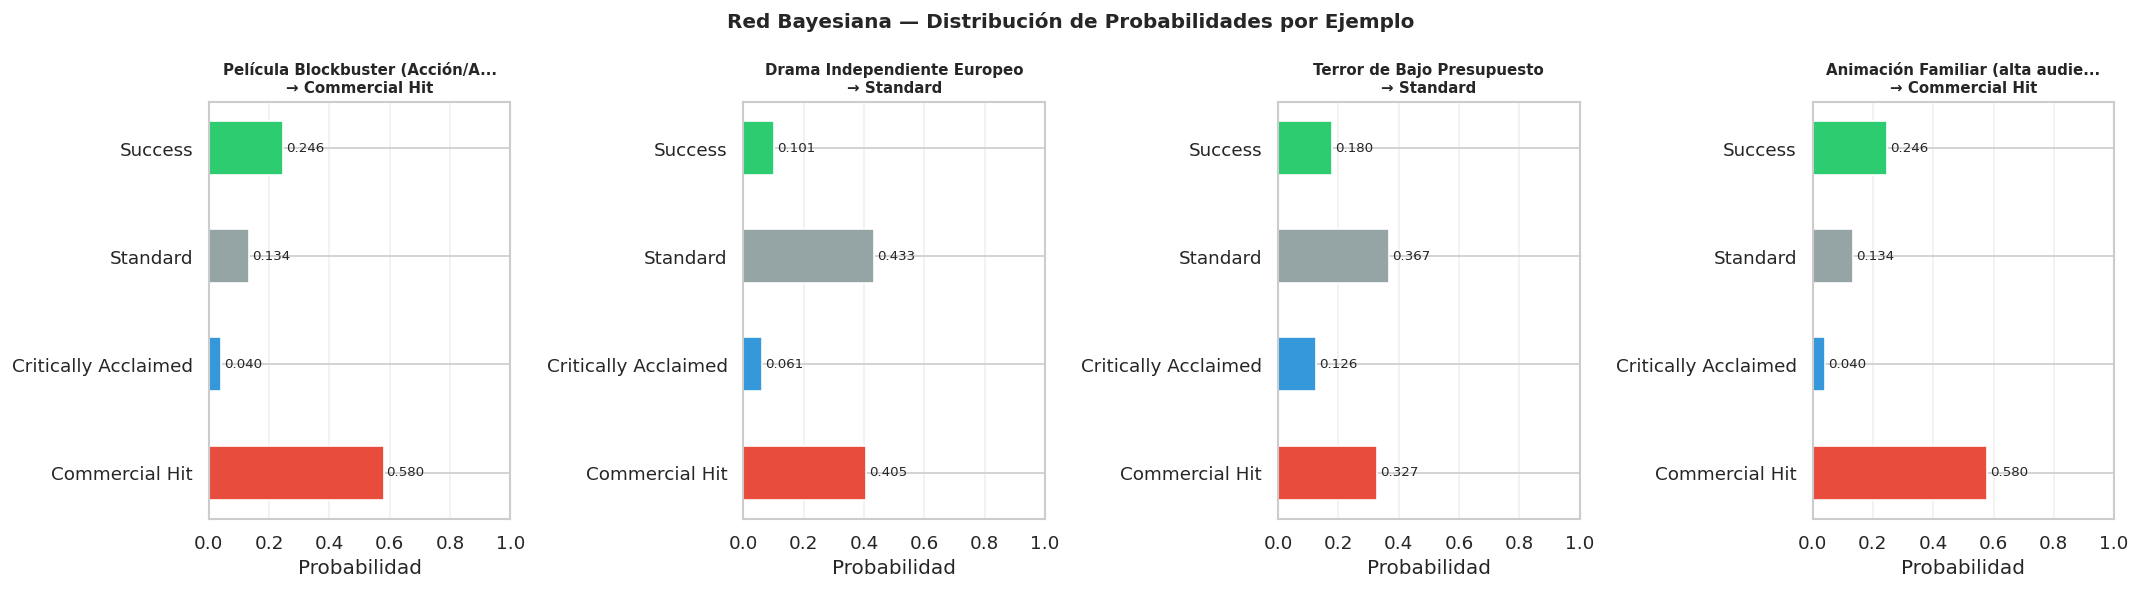

In [ ]:
# Visualización comparativa de predicciones
resultados_ejemplos = [r1, r2, r3, r4]

fig, axes = plt.subplots(1, len(resultados_ejemplos), figsize=(18, 5))
colores_cat = {
    'Success':               '#2ecc71',
    'Critically Acclaimed':  '#3498db',
    'Commercial Hit':        '#e74c3c',
    'Standard':              '#95a5a6',
}

for ax, res in zip(axes, resultados_ejemplos):
    cats  = list(res['probs_success'].keys())
    probs = list(res['probs_success'].values())
    bar_colors = [colores_cat.get(c, '#bdc3c7') for c in cats]

    bars = ax.barh(cats, probs, color=bar_colors, edgecolor='white', height=0.5)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Probabilidad')
    titulo_corto = res['titulo'][:30] + '...' if len(res['titulo']) > 30 else res['titulo']
    ax.set_title(f'{titulo_corto}\n→ {res["success_category_pred"]}',
                 fontweight='bold', fontsize=9)
    ax.grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, probs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Red Bayesiana — Distribución de Probabilidades por Ejemplo',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusiones — Redes Bayesianas

La aplicación de redes bayesianas al dataset cinematográfico de TMDB permitió construir un clasificador probabilístico interpretable que modela explícitamente las dependencias entre variables de producción.

**Resultados cuantitativos:**
Los modelos alcanzaron métricas razonables considerando la limitación fundamental de operar exclusivamente sobre 6 variables base (sin acceso a géneros ni componentes PCA para evitar data leakage). El F1-Score obtenido es inferior al de Random Forest, pero comparable al de Naive Bayes en ambas tareas, lo que demuestra que la red captura señal predictiva real con un conjunto de features estructuralmente reducido.

**Ventajas observadas:**
1. **Interpretabilidad causal:** Las CPTs permiten cuantificar cómo cada variable incrementa o reduce la probabilidad de que una película sea bien valorada, lo que aporta valor analítico más allá de la predicción pura.
2. **Inferencia con evidencia parcial:** El motor de eliminación de variables maneja automáticamente la ausencia de algunas features, a diferencia de modelos discriminativos que requieren el vector completo.
3. **Coherencia con el EDA:** Los patrones capturados por el modelo (vote_count como señal más informativa para highly_rated) son consistentes con las correlaciones identificadas durante el análisis exploratorio.

**Limitaciones y mejoras futuras:**
- Incorporar variables de texto mediante discretización de scores TF-IDF permitiría ampliar el espacio de features sin romper la restricción de variables discretas.
- El aprendizaje automático de estructura (algoritmos PC, HillClimbing con BIC score) podría revelar dependencias no consideradas en el diseño manual.
- Para el sistema de recomendación final, la Red Bayesiana resulta útil como **filtro de calidad probabilístico** previo a la búsqueda por similitud: en lugar de un umbral fijo, se pueden usar las probabilidades marginales para ponderar candidatos.